In [11]:
%%capture
%load_ext autoreload
%autoreload 2

%matplotlib inline

# To publish: jupyter nbconvert --to pdf --template citations.tplx --TemplateExporter.exclude_input=True final_report_sleep.ipynb

In [12]:
# Import local modules

import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# An Exploration of Sleep

In [13]:
%%capture
# Author: Sayan Faraz <sayan.faraz@mail.utoronto.ca>
# Starter code: https://mne.tools/dev/auto_tutorials/sample-datasets/plot_sleep.html
# Starter code authors: Alexandre Gramfort <alexandre.gramfort@inria.fr>
#                       Stanislas Chambon <stan.chambon@gmail.com>
#                       Joan Massich <mailsik@gmail.com>
# License: BSD 3 clause

import os
import os.path as op

# from download import download

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import mne
import pprint

from scipy import signal

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

import src.preprocess as preprocess

# from mne.time_frequency import psd_welch
# from mne_features.feature_extraction import FeatureExtractor

sns.set(font="Ubuntu")
sns.set_context("talk", font_scale=1.4)

default_figsize = (20, 4)

plt.rcParams["figure.figsize"] = default_figsize

pd.set_option('display.notebook_repr_html', True)
def _repr_latex_(self):
    return "\centering{%s}" % self.to_latex()
pd.DataFrame._repr_latex_ = _repr_latex_

print(__doc__)

In [14]:
RAND_STATE_INT = 10
rng = np.random.default_rng()

In [15]:
%%capture
# SETUP
# Note: the following code is sourced from the starter code, and is used for setup only.

SUBJECT = [0]
RECORDINGS=[1]

EPOCH_DURATION = 30.

mapping = {'EOG horizontal': 'eog',
           'Resp oro-nasal': 'misc',
           'EMG submental': 'misc',
           'Temp rectal': 'misc',
           'Event marker': 'misc'}

# Combining Sleep Stage 3 and 4
annotation_desc_2_event_id = {'Sleep stage W': 0,
                              'Sleep stage 1': 1,
                              'Sleep stage 2': 2,
                              'Sleep stage 3': 3,
                              'Sleep stage 4': 3,
                              'Sleep stage R': 4}

event_id = {'Sleep stage W': 0,
            'Sleep stage 1': 1,
            'Sleep stage 2': 2,
            'Sleep stage 3/4': 3,
            'Sleep stage R': 4}

raw, annot = preprocess.load_raw_recording(
    subjects=SUBJECT,
    recording=RECORDINGS,
    mapping=mapping
)

epochs = preprocess.epochs_from_recording(
    raw,
    annot,
    input_event_id=annotation_desc_2_event_id,
    out_event_id=event_id,
    epoch_duration=EPOCH_DURATION
)


In [16]:
sfreq = raw.info['sfreq']

fpz_ch = [raw.ch_names.index('EEG Fpz-Cz')]
eeg, t = raw[fpz_ch]

eeg = eeg / 1e-6 # EEG is typically measured in microvolts

(This notebook is an adaptation of an independent final project I did for my time series analysis course at the University of Toronto, where we had to pick any dataset and use time series analysis techniques to analyze the data.)

As much as us programmers love our coffee, sleep is actually what enables brain function when we're awake. There is evidence that memories are consolidated and toxins are removed from the brain when we sleep<cite data-cite="fultz_coupled_2019"></cite><cite data-cite="colten_chapter_2006"></cite>. There are five key stages of sleep: waking/restful state, Stage I, Stage II, Stage III/IV, and REM sleep <cite data-cite="colten_chapter_2006"></cite><cite data-cite="patel_physiology_2020"></cite>. The brain acts differently during each stage of sleep, and each stage plays a different role in preparing the brain for wakeful cognition. Usually, a trained technician can identify these stages by analyzing different measurements like eye movement, breathing, and brain waves in a process called polysomnography. But we can also do this using code to analyze brain waves directly!

Electroencephelography, or EEG, measures the electrical activity of the brain (brain waves!) caused by neurons firing action potentials. We can get an idea of this electrical activity by measuring voltage at different points on the skull in relation to a reference / ground (usually the mastoid bone right behind the ear, the nasion--where your nose connects to your face, or an earlobe). EEG captures an idea of the total electric field caused by all the action potentials happening at some point in time in the brain.

Your typical EEG graph actually doesn't look like much though, and you certainly won't be able to see the firings of individual neurons. Because skin is really good at resisting electricity, each neuron firing barely contributes to the measured voltage field. There's only a few cases where you can notice a change in EEG. First of all, only pyramidal neurons in the cortex (outermost layer) of the brain generally contribute to EEG at all. A large group of these neurons must fire together in synchrony in order for their voltage fields not to cancel each other out, and make a noticeable impact on EEG. This happens in two cases. Parts of the brain can respond in predictable ways to certain stimuli and exhibit noticeable patterns called **event-related potentials**. Large parts of the brain can also fire in synchrony due to the brain's overall state, causing observable **oscillations** in EEG.

findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not found.
findfont: Font family 'Ubuntu' not

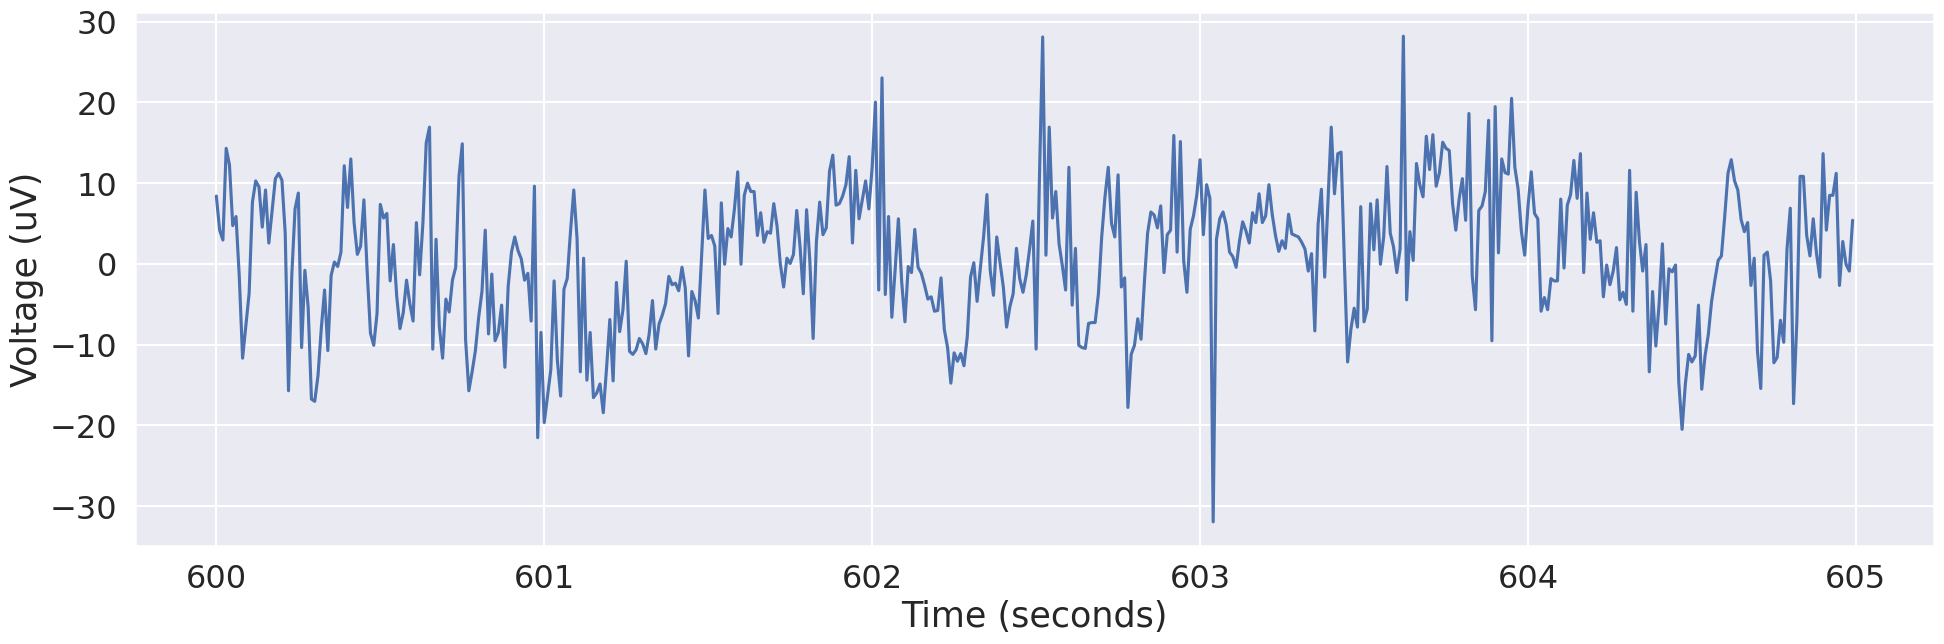

In [17]:
plt.rcParams["figure.figsize"] = (20, 7)
plt.rcParams['axes.titlepad'] = 20

rand_s, rand_e = preprocess.inds(start=600, duration=5, sfreq=sfreq)

plt.plot(t[rand_s:rand_e], (eeg.T)[rand_s:rand_e])
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (uV)")

plt.tight_layout()

plt.rcParams["figure.figsize"] = default_figsize

***Figure 1:*** It's really hard to tell what's happening in raw EEG

This last part is great, because the brain exhibits different oscillatory behaviour depending on which sleep state it is in! This gives us an idea of how to classify sleep stages, and in fact most automated sleep stage classifiers use machine learning to compare these oscillations and determine sleep stage. Therefore, it is useful to relate different oscillatory neurophysiological behaviour with concrete frequency bands. There are five such bands commonly defined in neuroscience: delta (<4Hz), theta (4-7Hz), alpha (7-12Hz), beta (12-30Hz), and gamma (>30Hz). <cite data-cite="cohen_chapter_2014"></cite><cite data-cite="imotions_neural_osc"></cite>

Because of different neurophysiological processes that happen in each sleep stage, EEG taken from different stages show different characteristics. The waking stage can be separated into two categories. When you're awake and ***active***, your brain has a high diversity of activity, and so in aggregate the wide range of brain waves interfere destructively with each other. In addition, there are characteristic beta frequencies that can be observed. However, during awake but ***relaxed***, states, there is less diversity in brain waves (and so more constructive interference, and therefore higher-amplitude activity). Most of this activity is in the alpha frequency.

Sleep itself can be divided into two key modes: rapid-eye-movement (REM) sleep, or sleep with dreams, and non-REM (NREM) sleep, or dreamless sleep. NREM sleep is further deviced into Stage I, Stage II, and Stage III/IV sleep. Each stage of sleep has distinguishable characteristics in the corresponding EEG: <cite data-cite="colten_chapter_2006"></cite><cite data-cite="patel_physiology_2020"></cite>


In [18]:
from IPython.display import HTML

characteristics = [
    ["Wakeful but resting", "Alpha waves dominate"],
    ["Stage I", "Delta and theta waves start replacing alpha"],
    ["Stage II", "K-complexes trigger more delta waves"],
    ["Stage III/IV", "Almost all acitivity is high-amplitude delta waves"],
    ["REM", "Lots of beta and gamma, sort of like awake and alert states"]
]

df = pd.DataFrame(characteristics, columns=['Stage', 'Characteristics in EEG'])

# Set CSS properties for th elements in dataframe
th_props = [
  ('font-size', '20px'),
  ('text-align', 'center'),
  ('font-weight', 'bold'),
]

# Set CSS properties for td elements in dataframe
td_props = [
  ('font-size', '20px')
]

# Set table styles
styles = [
  dict(selector="th", props=th_props),
  dict(selector="td", props=td_props)
]


(df.style.set_table_styles(styles))

,Stage,Characteristics in EEG
0,Wakeful but resting,Alpha waves dominate
1,Stage I,Delta and theta waves start replacing alpha
2,Stage II,K-complexes trigger more delta waves
3,Stage III/IV,Almost all acitivity is high-amplitude delta waves
4,REM,"Lots of beta and gamma, sort of like awake and alert states"


In [9]:
w_s, w_e = inds(start=500, duration=5, sfreq=sfreq)
sl_s, sl_e = inds(start=35000, duration=5, sfreq=sfreq)
rem_s, rem_e = inds(start=45100, duration=5, sfreq=sfreq)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:20: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


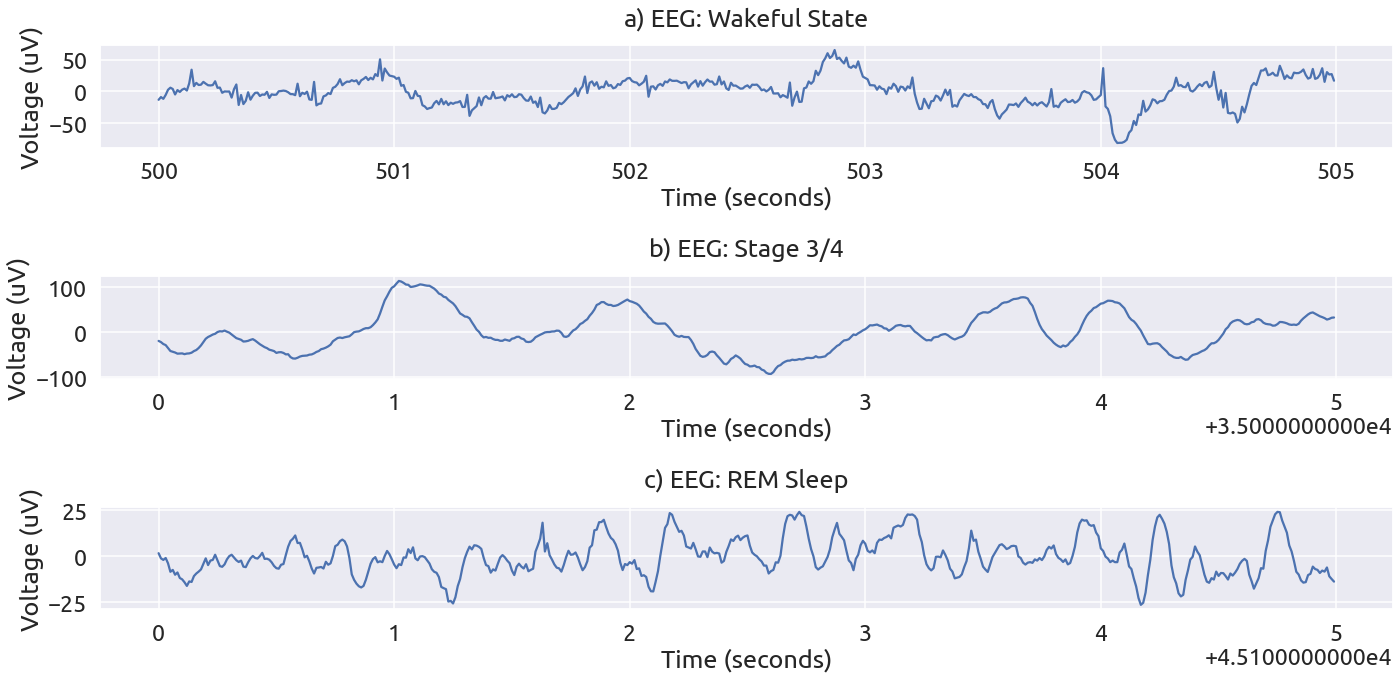

In [10]:
plt.rcParams["figure.figsize"] = (20, 10)

fig, axs = plt.subplots(3, 1, constrained_layout=True)

axs[0].plot(t[w_s:w_e], (eeg.T)[w_s:w_e])
axs[0].set_title("a) EEG: Wakeful State")
axs[0].set_xlabel("Time (seconds)")
axs[0].set_ylabel("Voltage (uV)")

axs[1].plot(t[sl_s:sl_e], (eeg.T)[sl_s:sl_e])
axs[1].set_title("b) EEG: Stage 3/4")
axs[1].set_xlabel("Time (seconds)")
axs[1].set_ylabel("Voltage (uV)")

axs[2].plot(t[rem_s:rem_e], (eeg.T)[rem_s:rem_e])
axs[2].set_title("c) EEG: REM Sleep")
axs[2].set_xlabel("Time (seconds)")
axs[2].set_ylabel("Voltage (uV)")

fig.tight_layout()

plt.rcParams["figure.figsize"] = default_figsize

***Figure 2:*** Brain waves look very different depending on what sleep state the subject is in.

In this notebook, I thought it would be fun to look at all these different characteristics in EEG. I'll extract power spectral features from sleep EEG data provided with the MNE EEG processing library, and compare them amongst different stages of sleep.<cite data-cite="kemp_analysis_2000"></cite><cite data-cite="goldberger_physiobank_2000"></cite><cite data-cite="chambon_deep_2018"></cite><cite data-cite="mne_sleep"></cite> These features include relative and absolute power distribution amongst frequency bands relevant to neuroscience, and total power output in EEG in different brain states.

## Our Game Plan

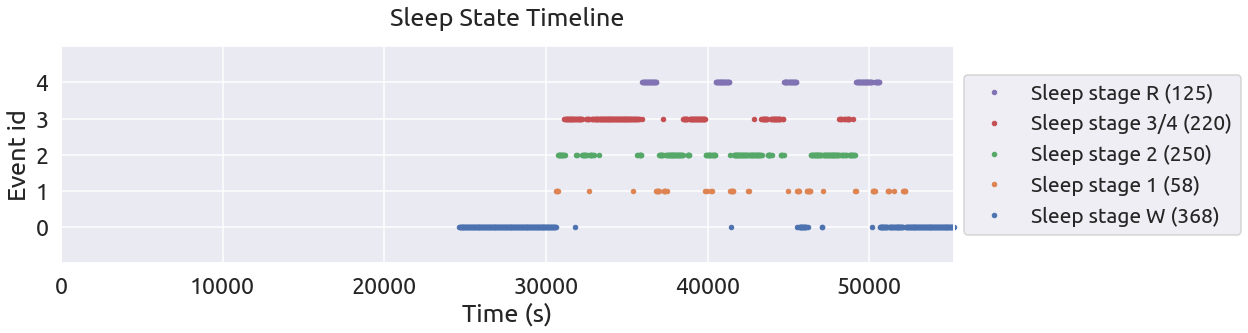

In [11]:
# FROM STARTER CODE
ax = plt.axes()
ax.set_title("Sleep State Timeline")
mne.viz.plot_events(events, event_id=event_id,
                    sfreq=raw.info['sfreq'], axes=ax)

# keep the color-code for further plotting
stage_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
# plt.rcParams["figure.figsize"] = default_figsize

***Figure 3:*** Sleep stages, as annotated through manual polysomnography. These annotations are used as ground-truth values for this report's analysis.

The dataset<cite data-cite="kemp_analysis_2000"></cite><cite data-cite="goldberger_physiobank_2000"></cite><cite data-cite="chambon_deep_2018"></cite><cite data-cite="mne_sleep"></cite> contains polysomnography data collected from one night of sleep each from two subjects. This data includes differential EEG between the Fpz and Cz locations, Pz and Oz locations, as well as horizontal eye movement EOG, respiratory monitoring, EMG, body temperature, and event markers labelling ground-truth sleep states derived manually by a technician. I'll only analyze differential EEG between the Fpz and Cz locations, which is measured at a sampling rate of 100Hz, but you can do the same thing for the other electrodes.

![](http://upload.wikimedia.org/wikipedia/commons/7/70/21_electrodes_of_International_10-20_system_for_EEG.svg)

***Figure 4:*** 10-20 system of placing electrodes. This system ensures standardizes electrode placement amongst all head sizes and shapes.


Relative bandpower is what it sounds like: the percentage of total power coming from a particular frequency band. This metric lets us quantitatively describe what we saw in Figure 2 above.

First, I estimate the power spectral density (power per Hz) of an EEG sample $f(t)$. Figure 4 shows a periodogram estimate for the power spectrum, where $dt$ is the time elapsed between two samples, $N$ is the length of the discretized sample, and $f_s$ is the sampling frequency (and so therefore equal to $\frac{1}{dt}$ ):

$$psd(\omega) = \frac{1}{N} {\vert F(\omega)\vert}^2 dt = \frac{ {\vert F(\omega)\vert}^2 }{Nf_s} $$

where $F(\omega)$ is the Fourier Transform (FT) of the preprocessed EEG signal. To preprocess the EEG signal, I first removed any linear trends in the signal, and then multiplied it by a Hann window function. Fourier Transforms technically assume an infinitely long periodic signal. But because we're computing the FT of a finite signal which therefore have discontinuities at the end, these discontinuities result in non-sensical high-frequency components being present in the FT. A window function smooths the ends to zero, reducing the amplitude of these non-sensical components.

![](https://zone.ni.com/images/reference/en-XX/help/371361R-01/guid-12ee66d8-d6ba-4aab-9373-1a0e5a6347a6-help-web.png)

***Figure 5:*** Windowing functions smooth discontinuities at the end of a finite signal, reducing spectral leakage from introduced high-frequency components because of the discontinuity

In [12]:
def get_bands():
    """
        Return a dictionary of frequency bands and their labels in the form of (low, high].
    """
    return {
        'delta': (0, 4),
        'theta': (4, 7),
        'alpha': (7, 12),
        'beta': (12, 30),
        'gamma': (30, 50)
    }

def detrend(data, sfreq):
    t = np.arange(0.0, data.shape[0])/sfreq

    trend_coeffs = np.polyfit(t, data, 1)
    trendline = t*trend_coeffs[0] + trend_coeffs[1]

    return data - trendline

def detrend_v(data, sfreq):
    t = np.arange(0.0, data.shape[0])/sfreq

    trend_coeffs = np.polyfit(t, data, 1)
    trendline = t[:,np.newaxis]*trend_coeffs[0].T + trend_coeffs[1, np.newaxis]

    return data - trendline

def hann(data):
    return data*(1.0-np.cos(2*np.pi*np.arange(0, data.shape[0])/data.shape[0]))

def hann_v(data):
    return data*(1.0-np.cos(2*np.pi*np.arange(0, data.shape[0])/data.shape[0]))[:, np.newaxis]

def power_spec(data, sfreq, window=True, one_sided=True, vectorized=True):
    if vectorized:
        data_preproc = hann_v(detrend_v(data, sfreq)) if window else detrend_v(data, sfreq)
    else:
        data_preproc = hann(detrend(data, sfreq)) if window else detrend(data, sfreq)
    
    fourier = np.fft.fft(data_preproc)
    fourier_ = np.conj(fourier)
    
    dt = 1.0/sfreq
    power_spec = fourier_*fourier * 1/data_preproc.shape[0] * dt
    freq = np.fft.fftfreq(data_preproc.shape[0], d=1.0/sfreq)
    
    if one_sided:
        return freq[(0 < freq)], power_spec[(0 < freq)]
    else:
        return freq, power_spec

# def power_spec_v(data, sfreq, window=True, one_sided=True):
#     data_preproc = hann_v(detrend_v(data, sfreq)) if window else detrend_v(data, sfreq)

#     fourier = np.fft.fft(data_preproc, axis=0)
#     fourier_ = np.conj(fourier)

#     dt = 1.0/sfreq
#     power_spec = fourier_*fourier * 1/data_preproc.shape[0] * dt
#     freq = np.fft.fftfreq(data_preproc.shape[0], d=1.0/sfreq)
    
#     if one_sided:
#         return freq[(0 < freq)], power_spec[(0 < freq)]
#     else:
#         return freq, power_spec

Then I calculated bandpower by integrating the power spectral density function over the frequency band in question, ie 4-7Hz for the theta band:

$$bp(x, f_{lower}, f_{upper}) = \int_{f_{lower}}^{f_{upper}}psd(\omega)d\omega$$

$$bp_{relative}(x, f_{lower}, f_{upper}) = \frac{bp(x, f_{lower}, f_{upper})}{bp(x, 0, \infty)}$$

To extract relative bandpowers from EEG data, you'd perform the following general steps: remove noise, epoch your data, and calculate relative bandpower per epoch. The most significant source of noise in EEG is AC noise from surrounding electronics. This is typically 60Hz in North America, and 50Hz in other parts of the world. However, the dataset analyzed was sampled at 100Hz. But Nyquist Theorem says that you'll only see frequencies less than 100/2=50Hz in the dataset, so any possible 50Hz or 60Hz component isn't accuractely represented in the dataset. So we can skip the noise removal step! #yay! However, if the dataset was sampled at a higher rate, we could apply notch filter at either 50Hz or 60Hz to the data in the following fashion:

$$B_{notch}(z) = \frac{z-q}{z-p},\qquad p=(1+\epsilon)e^{-i\omega_0},  q=e^{-i\omega_0}$$

In [13]:
# ---------------------------------- REGULAR

def get_bands():
    """
        Return a dictionary of frequency bands and their labels in the form of (low, high].
    """
    return {
        'delta': (0, 4),
        'theta': (4, 7),
        'alpha': (7, 12),
        'beta': (12, 30),
        'gamma': (30, 50)
    }

def detrend(data, sfreq):
    t = np.arange(0.0, data.shape[0])/sfreq

    trend_coeffs = np.polyfit(t, data, 1)
    trendline = t*trend_coeffs[0] + trend_coeffs[1]

    return data - trendline

def hann(data):
    return data*(1.0-np.cos(2*np.pi*np.arange(0, data.shape[0])/data.shape[0]))

def power_spec(data, sfreq, window=True, one_sided=True):
    data_preproc = hann(detrend(data, sfreq)) if window else detrend(data, sfreq)
    
    fourier = np.fft.fft(data_preproc)
    fourier_ = np.conj(fourier)
    
    dt = 1.0/sfreq
    power_spec = fourier_*fourier * 1/data_preproc.shape[0] * dt
    freq = np.fft.fftfreq(data_preproc.shape[0], d=1.0/sfreq)
    
    if one_sided:
        return freq[(0 < freq)], power_spec[(0 < freq)]
    else:
        return freq, power_spec

def bandpower(data, sfreq, window=True, relative=True, include_total=False):
    ret_bandpower = {}
    bands = get_bands()
    freq, power = power_spec(data, sfreq, window=window, one_sided=True)

    total_power = np.abs(np.trapz(power, freq))
    div_total_power = total_power if relative else 1.0

    for band, freq_bounds in bands.items():
        l_ind = np.argwhere(freq>freq_bounds[0])[0, 0]
        h_ind = np.argwhere(freq<=freq_bounds[1])[-1, 0]
        bpow = np.trapz(power[l_ind:h_ind], freq[l_ind:h_ind])
        ret_bandpower[band] = bpow / total_power
    if include_total:
        ret_bandpower['total'] = total_power if not relative else 1.0
    return ret_bandpower

In [14]:
# ---------------------------------- VECTORIZED

def get_bands():
    """
        Return a dictionary of frequency bands and their labels in the form of (low, high].
    """
    return {
        'delta': (0, 4),
        'theta': (4, 7),
        'alpha': (7, 12),
        'beta': (12, 30),
        'gamma': (30, 50)
    }

def detrend_v(data, sfreq):
    t = np.arange(0.0, data.shape[0])/sfreq

    trend_coeffs = np.polyfit(t, data, 1)
    trendline = t[:,np.newaxis]*trend_coeffs[0].T + trend_coeffs[1, np.newaxis]

    return data - trendline

def hann_v(data):
    return data*(1.0-np.cos(2*np.pi*np.arange(0, data.shape[0])/data.shape[0]))[:, np.newaxis]

def power_spec_v(data, sfreq, window=True, one_sided=True):
    data_preproc = hann_v(detrend_v(data, sfreq)) if window else detrend_v(data, sfreq)

    fourier = np.fft.fft(data_preproc, axis=0)
    fourier_ = np.conj(fourier)

#     power_spec = fourier_*fourier*(1.0/(sfreq*data_preproc.shape[0]))
    
    dt = 1.0/sfreq
    power_spec = fourier_*fourier * 1/data_preproc.shape[0] * dt
    freq = np.fft.fftfreq(data_preproc.shape[0], d=1.0/sfreq)
    
    if one_sided:
        return freq[(0 < freq)], power_spec[(0 < freq)]
    else:
#         _, power_spec = signal.periodogram(x=data_preproc, fs=sfreq, return_onesided=False, scaling='density')
        return freq, power_spec

def bandpower_v(data, sfreq, window=True, relative=True, include_total=False):
    ret_bandpower = {}
    bands = get_bands()
    freq, power = power_spec_v(data, sfreq, window=window, one_sided=True)
    # print("Freq: ", freq.shape)
    # print("Power: ", power.shape)

    total_power = np.abs(np.trapz(power, freq, axis=0))
    div_total_power = total_power if relative else 1.0
    # print("Total power: ", total_power.shape)

    for band, freq_bounds in bands.items():
        # print("BAND: ", band)
        l_ind = np.argwhere(freq>freq_bounds[0])[0, 0]
        h_ind = np.argwhere(freq<=freq_bounds[1])[-1, 0]
        # print("Ind: ", l_ind, h_ind)
        # print("Freq: ", freq[l_ind], freq[h_ind])
        # print("-----------------------------------")
        bpow = np.abs(np.trapz(power[l_ind:h_ind], freq[l_ind:h_ind], axis=0))
        ret_bandpower[band] = bpow / div_total_power
    if include_total:
        ret_bandpower['total'] = total_power if not relative else 1.0
    return ret_bandpower

I divided the dataset into 30-second epochs, mostly because event markers are given for 30-second epochs. But this epoch length actually make sense when analyzing sleep EEG. I'm trying to analyze frequencies within (0-50]Hz. Given a samplng rate of 100Hz, a frequency range of [-50, 50]Hz can be represented accurately, which encompasses the frequency range we are interested in. Also, note that we are interested in integrating the power spectrum in a particular band. So using a trapezoidal area calculation should be good enough when dealing with frequency differences of, ie, 0.25Hz, and a 0.5Hz frequency resolution is great! So let's try to get that. To get a 0.5Hz frequency resolution, we'd need at least 2 seconds of data by Nyquist's theorem. But brain activity is dynamic, and we're interested in frequency oscillations lasting around the order of minutes. This is the amount of time a person would, for example, wake up and fall back asleep, or transition to another sleep stage. So an epoch length of 30s to a minute is perfect!

## Plotting time

We're finally ready to analyze the data! Let's start with some power spectra:


<!-- We aggregate relative bandpower values amongst epochs in a particular sleep state (based on event markers) and compute a 5-number summary (0, 25, 50, 75, and 100th percentiles). We compare the results to what's expected from neuroscience literature, and discuss the relationship between neurological processes and quantitative measurements due to electromagnetic interactions. <cite data-cite="jones_fourier_2020"></cite><cite data-cite="jones_dft_2020"></cite><cite data-cite="jones_fft_2020"></cite><cite data-cite="jones_df_2020"></cite><cite data-cite="jones_stochastic_2020"></cite><cite data-cite="jones_power_spec_2020"></cite> -->

In [15]:
wake_s, wake_e = inds(start=500, duration=5, sfreq=sfreq) #500
siii_s, siii_e = inds(start=35000, duration=5, sfreq=sfreq) #35000
rem_s, rem_e = inds(start=45100, duration=5, sfreq=sfreq) #45100

wake_freq, wake_power = power_spec_v((eeg.T)[wake_s:wake_e, 0, np.newaxis], sfreq, window=True, one_sided=True)
siii_freq, siii_power = power_spec_v((eeg.T)[siii_s:siii_e, 0, np.newaxis], sfreq, window=True, one_sided=True)
rem_freq, rem_power = power_spec_v((eeg.T)[rem_s:rem_e, 0, np.newaxis], sfreq, window=True, one_sided=True)

/opt/conda/lib/python3.7/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/opt/conda/lib/python3.7/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/opt/conda/lib/python3.7/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


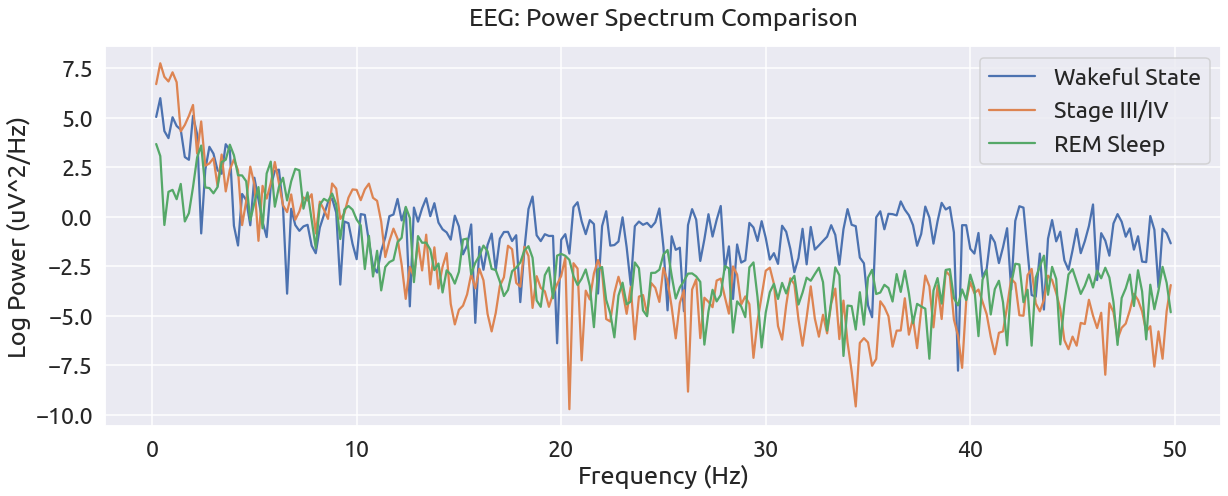

In [16]:
plt.rcParams["figure.figsize"] = (20,7)

plt.plot(wake_freq, np.log(wake_power), label="Wakeful State")
plt.plot(siii_freq, np.log(siii_power), label="Stage III/IV")
plt.plot(rem_freq, np.log(rem_power), label="REM Sleep")

plt.title("EEG: Power Spectrum Comparison")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Log Power (uV^2/Hz)")
plt.legend()
plt.rcParams["figure.figsize"] = default_figsize

***Figure 6:***  Power spectral density calculated for three 5-second samples of EEG from wakeful state, Stage III/IV sleep, and REM sleep.

You can start seeing the differences in EEG we saw in Figure 3, but now in frequency form! The part of the power spectrum plot corresponding to delta waves (0-5Hz) is higher in Stage III/IV than in wakful and REM sleep states.

Let's try and quantify this by looking at the actual bandpowers:

In [17]:
wake_pow_rel = bandpower((eeg.T)[wake_s:wake_e, 0], sfreq, relative=True)
siii_pow_rel = bandpower((eeg.T)[siii_s:siii_e, 0], sfreq, relative=True)
rem_pow_rel = bandpower((eeg.T)[rem_s:rem_e, 0], sfreq, relative=True)

wake_pow_abs = bandpower((eeg.T)[wake_s:wake_e, 0], sfreq, relative=False)
siii_pow_abs = bandpower((eeg.T)[siii_s:siii_e, 0], sfreq, relative=False)
rem_pow_abs = bandpower((eeg.T)[rem_s:rem_e, 0], sfreq, relative=False)

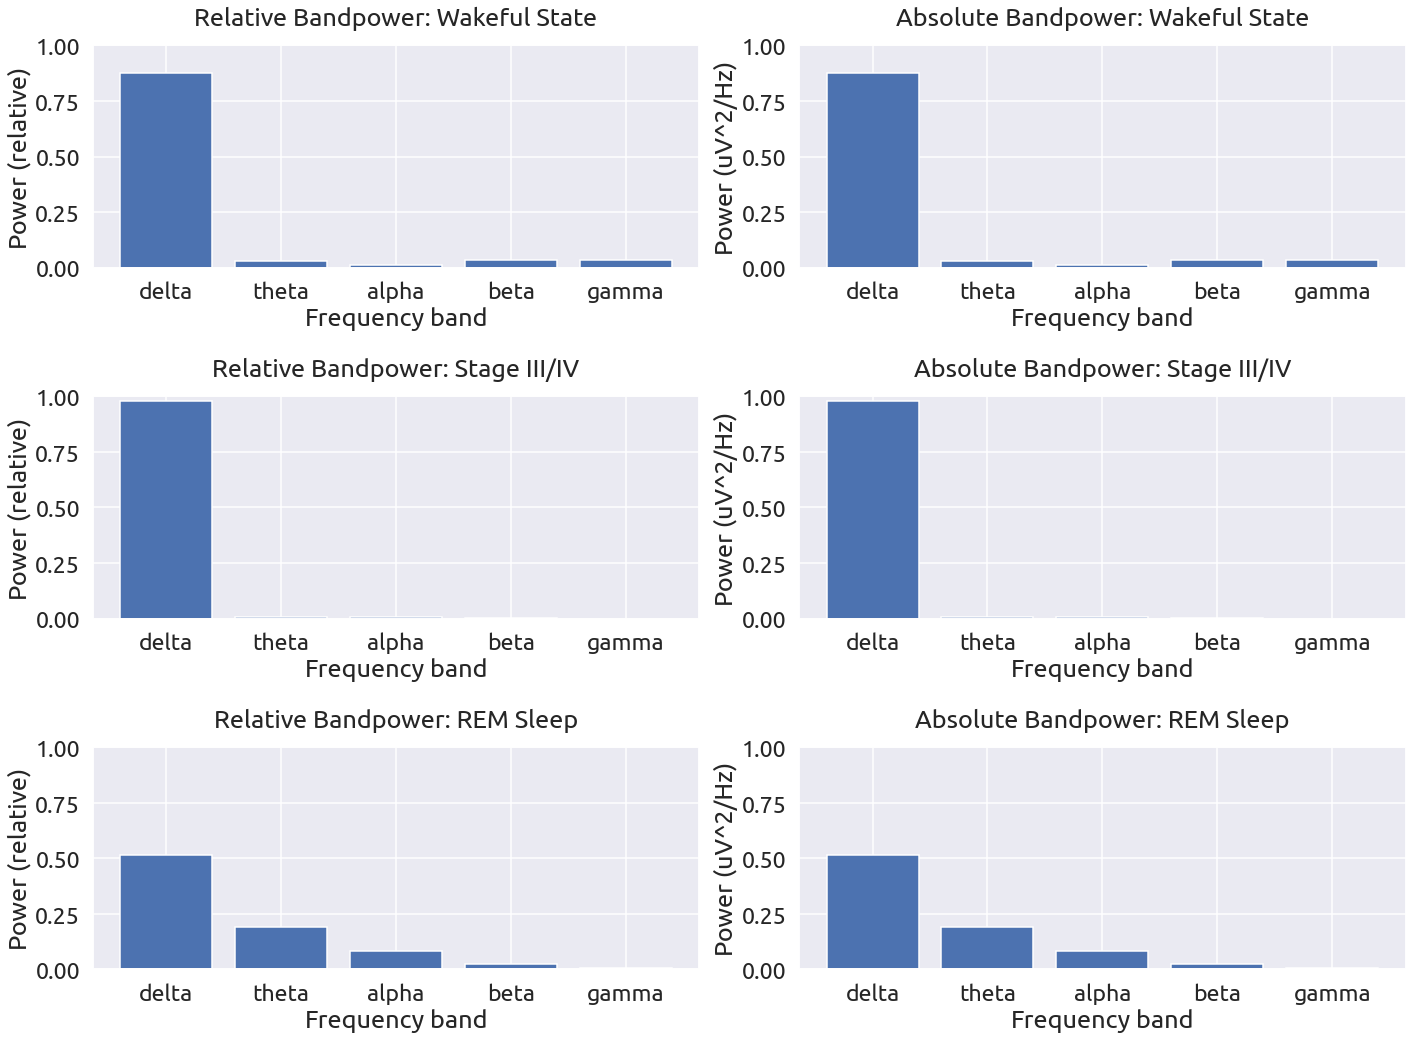

In [18]:
plt.rcParams["figure.figsize"] = (20,15)

plt.subplot(321)
plt.bar(*zip(*wake_pow_rel.items()))
plt.title("Relative Bandpower: Wakeful State")
plt.xlabel("Frequency band")
plt.ylabel("Power (relative)")
plt.ylim(0, 1)

plt.subplot(322)
plt.bar(*zip(*wake_pow_abs.items()))
plt.title("Absolute Bandpower: Wakeful State")
plt.xlabel("Frequency band")
plt.ylabel("Power (uV^2/Hz)")
plt.ylim(0, 1)


plt.subplot(323)
plt.bar(*zip(*siii_pow_rel.items()))
plt.title("Relative Bandpower: Stage III/IV")
plt.xlabel("Frequency band")
plt.ylabel("Power (relative)")
plt.ylim(0, 1)

plt.subplot(324)
plt.bar(*zip(*siii_pow_abs.items()))
plt.title("Absolute Bandpower: Stage III/IV")
plt.xlabel("Frequency band")
plt.ylabel("Power (uV^2/Hz)")
plt.ylim(0, 1)


plt.subplot(325)
plt.bar(*zip(*rem_pow_rel.items()))
plt.title("Relative Bandpower: REM Sleep")
plt.xlabel("Frequency band")
plt.ylabel("Power (relative)")
plt.ylim(0, 1)

plt.subplot(326)
plt.bar(*zip(*rem_pow_abs.items()))
plt.title("Absolute Bandpower: REM Sleep")
plt.xlabel("Frequency band")
plt.ylabel("Power (uV^2/Hz)")
plt.ylim(0, 1)

plt.tight_layout()

plt.rcParams["figure.figsize"] = default_figsize

***Figure 7:*** Absolute and relative bandpower calculated for three 5-second samples of EEG from wakeful state, Stage III/IV sleep, and REM sleep.



You can really start seeing the differences between the stages here! Stage III/IV barely has any non-delta activity, while REM sleep and wakeful states have much lower delta activity. There's a surprising amunt of alpha in the REM sleep sample which is interesting as well.

All of this was just from one sample though! Let's see if we can see similar patterns in a boxlot:

In [19]:
sleep_stage_rel_bandpower = {}
sleep_stage_abs_bandpower = {}

for event, e_id in event_id.items():
    print(event, "( id", e_id, ")")

    sub_epochs = epochs[event].get_data()
    print("Epoch shape: ", (sub_epochs[:, raw.ch_names.index('EEG Fpz-Cz'), :].T).shape, "\n")
    sleep_stage_rel_bandpower[event] = bandpower_v(sub_epochs[:, raw.ch_names.index('EEG Fpz-Cz'), :].T, sfreq, relative=True, include_total=False)
    sleep_stage_abs_bandpower[event] = bandpower_v(sub_epochs[:, raw.ch_names.index('EEG Fpz-Cz'), :].T, sfreq, relative=False, include_total=True)

Sleep stage W ( id 0 )
Loading data for 368 events and 3000 original time points ...
0 bad epochs dropped
Epoch shape:  (3000, 368) 

Sleep stage 1 ( id 1 )
Loading data for 58 events and 3000 original time points ...
0 bad epochs dropped
Epoch shape:  (3000, 58) 

Sleep stage 2 ( id 2 )
Loading data for 250 events and 3000 original time points ...
0 bad epochs dropped
Epoch shape:  (3000, 250) 

Sleep stage 3/4 ( id 3 )
Loading data for 220 events and 3000 original time points ...
0 bad epochs dropped
Epoch shape:  (3000, 220) 

Sleep stage R ( id 4 )
Loading data for 125 events and 3000 original time points ...
0 bad epochs dropped
Epoch shape:  (3000, 125) 



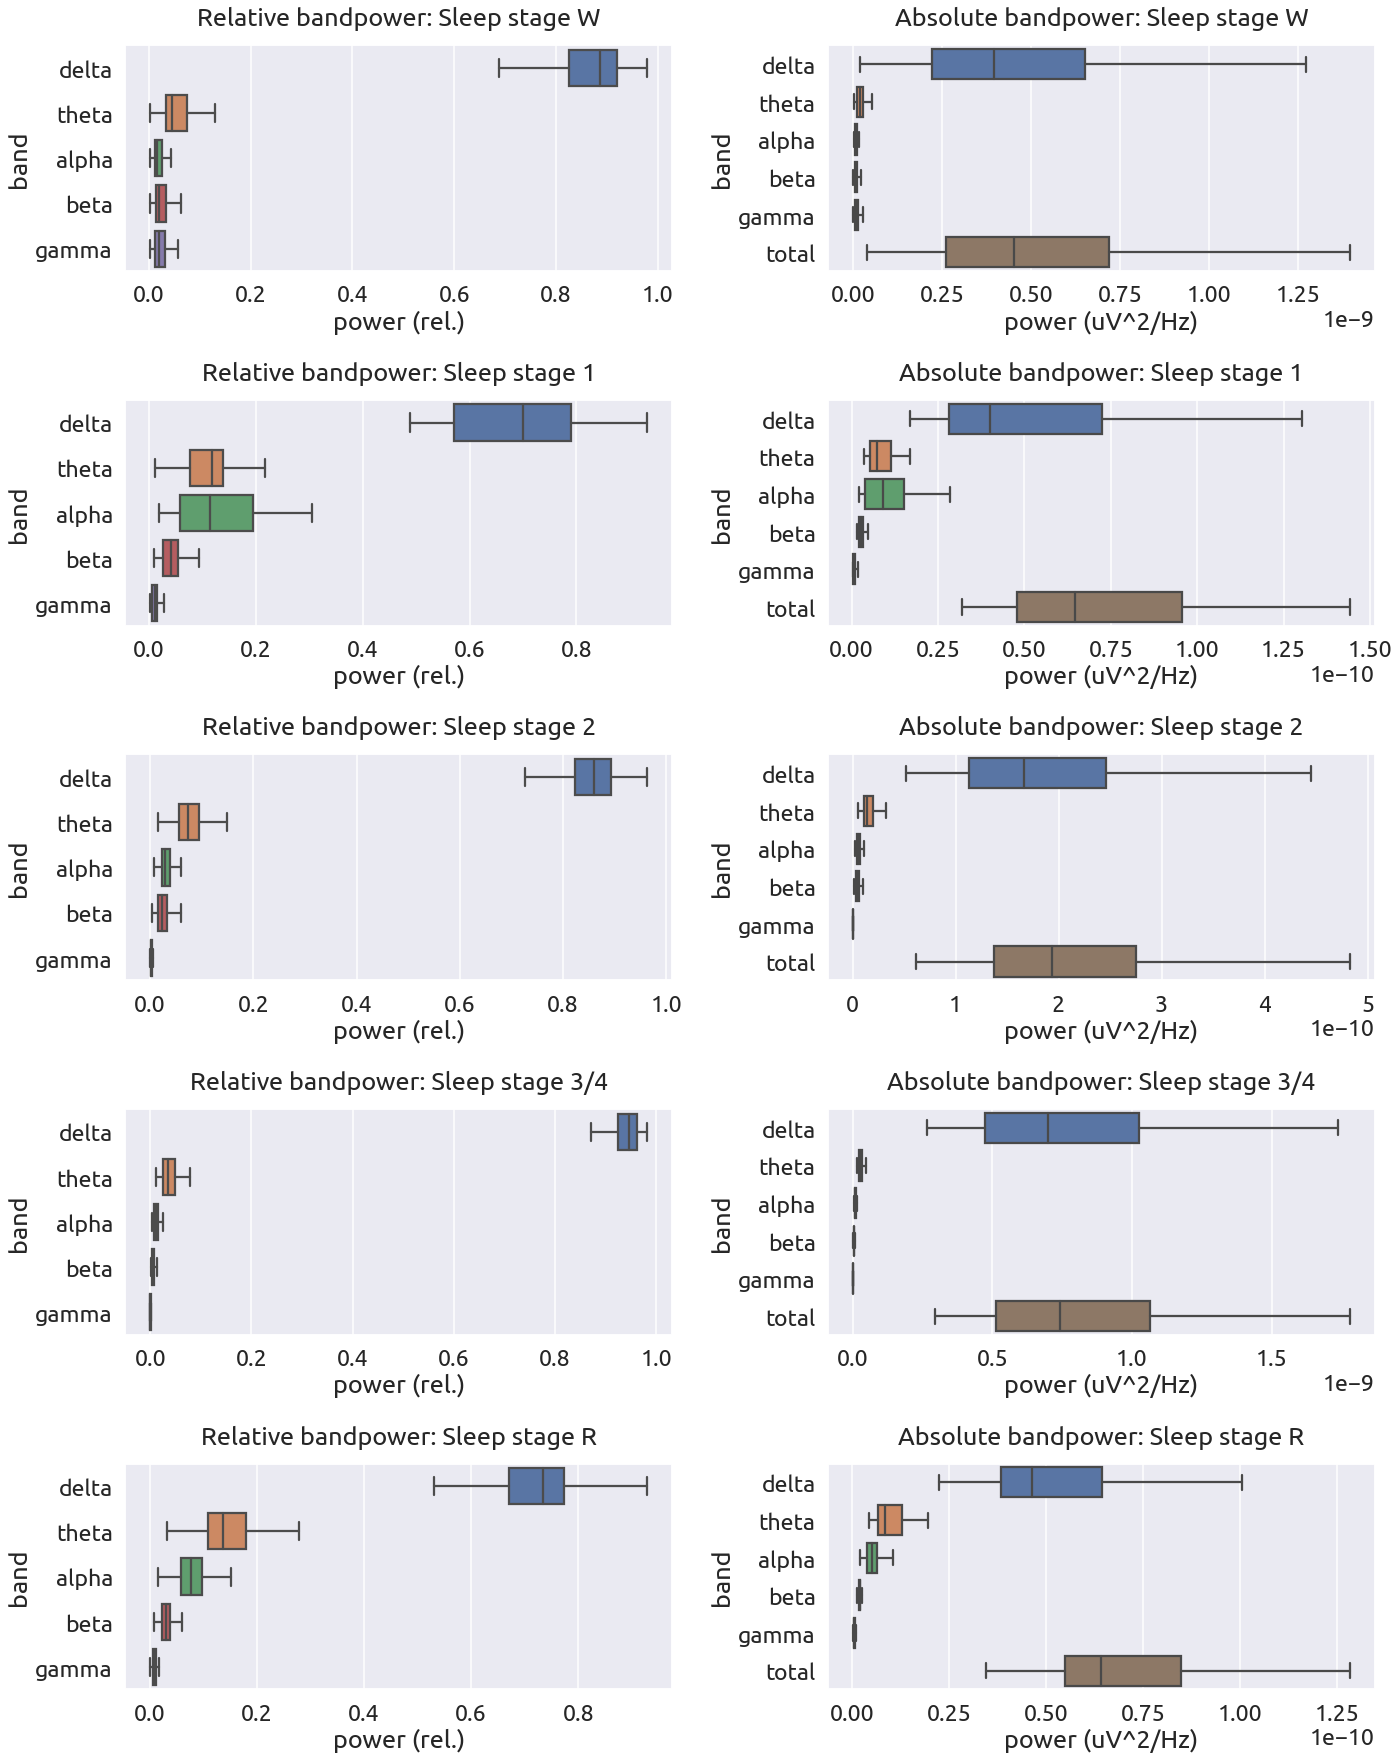

In [20]:
plt.rcParams["figure.figsize"] = (20,25)
plt.subplot()

nrows = len(event_id.keys())
ncols = 2
subplot_count = 1

for event, e_id  in event_id.items():
    sub_epoch_pow_rel_df = pd.DataFrame.from_dict(sleep_stage_rel_bandpower[event]).melt().rename(columns={'variable': 'band', 'value': 'power (rel.)'})
    sub_epoch_pow_abs_df = pd.DataFrame.from_dict(sleep_stage_abs_bandpower[event]).melt().rename(columns={'variable': 'band', 'value': 'power (uV^2/Hz)'})

    # subplot_id = str(len(event_id.keys())) + "2" + str(subplot_count)
    plt.subplot(nrows, ncols, subplot_count)
    sns.boxplot(x='power (rel.)', y='band', data=sub_epoch_pow_rel_df, showfliers = False)# , scale="width")
    plt.title("Relative bandpower: " + event)

    subplot_count += 1

    # subplot_id = str(len(event_id.keys())) + "2" + str(subplot_count)
    plt.subplot(nrows, ncols, subplot_count)
    sns.boxplot(x='power (uV^2/Hz)', y='band', data=sub_epoch_pow_abs_df, showfliers = False) #, scale="width")
    plt.title("Absolute bandpower: " + event)

    subplot_count += 1

plt.tight_layout()

***Figure 8:*** Boxplot of relative and absolute bandpowers in different sleep stages.

And here's a 5-number summary for good measure:

In [21]:
def five_num_summary(data):
    # print(data)
    perc_25 = np.percentile(data, 25)
    perc_50 = np.percentile(data, 50)
    perc_75 = np.percentile(data, 75)

    iqr = perc_75 - perc_25
    perc_0 = np.min(data[data >= (perc_25 - 1.5*iqr)])
    perc_100 = np.max(data[data <= (perc_75 + 1.5*iqr)])

    num_outliers_lower = data[(data < (perc_25 - 1.5*iqr))].shape[0]
    num_outliers_upper = data[(data > (perc_75 + 1.5*iqr))].shape[0]

    return {
        "0%": perc_0,
        "25%": perc_25,
        "50%": perc_50,
        "75%": perc_75,
        "100%": perc_100,
        "# of Outliers (lower)": num_outliers_lower,
        "# of Outliers (upper)": num_outliers_upper,
    }

def bandpower_five_num_summary(data):
    ret_five_num_summary = {}
    for event in event_id.keys():
        event_five_num_summary = {}
        for band in data[event].keys():
            event_five_num_summary[band] = five_num_summary(data[event][band])
        ret_five_num_summary[event] = event_five_num_summary
    return ret_five_num_summary

In [22]:
five_num_summ_file = open('five_num_summ_file.txt', 'w') 

five_num_summary_rel_bpwr = bandpower_five_num_summary(sleep_stage_rel_bandpower)
five_num_summary_abs_bpwr = bandpower_five_num_summary(sleep_stage_abs_bandpower)

print("RELATIVE BANDPOWER: 5-NUM SUMMARY\n", pprint.pformat(five_num_summary_rel_bpwr, indent=2), file=five_num_summ_file)

print("ABSOLUTE BANDPOWER: 5-NUM SUMMARY\n", pprint.pformat(five_num_summary_abs_bpwr, indent=2), file=five_num_summ_file)

five_num_summ_file.close()

In [23]:
pd.set_option("precision", 7)

five_num_summary_rel_bpwr_df = pd.DataFrame.from_dict({(i,j): five_num_summary_rel_bpwr[i][j] 
                           for i in five_num_summary_rel_bpwr.keys() 
                           for j in five_num_summary_rel_bpwr[i].keys()},
                       orient='index')

five_num_summary_rel_bpwr_df = five_num_summary_rel_bpwr_df.rename_axis("Percentile", axis="columns")
five_num_summary_rel_bpwr_df = five_num_summary_rel_bpwr_df.rename_axis(["Sleep Stage", "Freq. Band"], axis="index")

five_num_summary_rel_bpwr_df = five_num_summary_rel_bpwr_df.drop("# of Outliers (lower)", "columns")
five_num_summary_rel_bpwr_df = five_num_summary_rel_bpwr_df.drop("# of Outliers (upper)", "columns")

pd.set_option('display.max_columns', None)
five_num_summary_rel_bpwr_df.T

Sleep Stage Sleep stage W                                              \
Freq. Band          delta      theta      alpha       beta      gamma   
Percentile                                                              
0%              0.6884717  0.0031782  0.0029774  0.0032812  0.0032164   
25%             0.8260379  0.0335748  0.0112189  0.0135014  0.0123352   
50%             0.8863260  0.0463505  0.0151196  0.0197471  0.0203929   
75%             0.9188992  0.0743164  0.0254910  0.0332953  0.0314970   
100%            0.9795428  0.1308866  0.0438728  0.0629006  0.0577866   

Sleep Stage Sleep stage 1                                              \
Freq. Band          delta      theta      alpha       beta      gamma   
Percentile                                                              
0%              0.4885020  0.0120696  0.0188894  0.0094236  0.0027531   
25%             0.5702042  0.0769274  0.0582174  0.0272456  0.0062098   
50%             0.7002084  0.1176802  0.1136302  0.0410284  0.0108200   
75%             0.7898479  0.1384654  0.1957155  0.0544473  0.0152100   
100%            0.9327185  0.2172067  0.3051789  0.0945365  0.0277267   

Sleep Stage Sleep stage 2                                              \
Freq. Band          delta      theta      alpha       beta      gamma   
Percentile                                                              
0%              0.7258765  0.0156990  0.0071793  0.0046207  0.0005187   
25%             0.8234017  0.0568090  0.0222580  0.0144680  0.0013829   
50%             0.8590158  0.0738697  0.0282225  0.0231674  0.0021950   
75%             0.8930255  0.0946414  0.0379173  0.0327650  0.0030137   
100%            0.9631485  0.1485523  0.0606103  0.0591644  0.0051771   

Sleep Stage Sleep stage 3/4                                              \
Freq. Band            delta      theta      alpha       beta      gamma   
Percentile                                                                
0%                0.8705669  0.0119656  0.0033001  0.0007926  0.0001299   
25%               0.9239109  0.0246740  0.0081123  0.0027941  0.0002860   
50%               0.9467868  0.0346516  0.0107740  0.0045866  0.0004589   
75%               0.9614450  0.0491860  0.0151210  0.0073946  0.0007951   
100%              0.9825070  0.0776022  0.0252343  0.0137594  0.0015578   

Sleep Stage Sleep stage R                                              
Freq. Band          delta      theta      alpha       beta      gamma  
Percentile                                                             
0%              0.5303529  0.0329826  0.0158663  0.0077827  0.0014326  
25%             0.6701612  0.1089704  0.0580252  0.0239561  0.0071518  
50%             0.7331680  0.1378100  0.0768633  0.0308743  0.0095155  
75%             0.7740475  0.1801050  0.0982622  0.0386300  0.0120029  
100%            0.9288889  0.2793487  0.1521215  0.0605414  0.0178297

***Table 1:*** 5-number summary for relative bandpowers in each stage of sleep.

In [24]:
pd.set_option("precision", 2)

five_num_summary_abs_bpwr_df = pd.DataFrame.from_dict({(i,j): five_num_summary_abs_bpwr[i][j] 
                           for i in five_num_summary_abs_bpwr.keys() 
                           for j in five_num_summary_abs_bpwr[i].keys()},
                       orient='index')

five_num_summary_abs_bpwr_df = five_num_summary_abs_bpwr_df.rename_axis("Percentile", axis="columns")
five_num_summary_abs_bpwr_df = five_num_summary_abs_bpwr_df.rename_axis(["Sleep Stage", "Freq. Band"], axis="index")

five_num_summary_abs_bpwr_df = five_num_summary_abs_bpwr_df.drop("# of Outliers (lower)", "columns")
five_num_summary_abs_bpwr_df = five_num_summary_abs_bpwr_df.drop("# of Outliers (upper)", "columns")

pd.set_option('display.max_columns', None)
five_num_summary_abs_bpwr_df.T

Sleep Stage Sleep stage W                                                    \
Freq. Band          delta     theta     alpha      beta     gamma     total   
Percentile                                                                    
0%               2.04e-11  3.96e-12  2.30e-12  1.69e-12  5.05e-13  3.91e-11   
25%              2.23e-10  1.26e-11  5.74e-12  5.37e-12  5.96e-12  2.63e-10   
50%              3.96e-10  2.09e-11  7.99e-12  8.76e-12  1.03e-11  4.52e-10   
75%              6.52e-10  2.98e-11  1.07e-11  1.29e-11  1.47e-11  7.18e-10   
100%             1.27e-09  5.36e-11  1.82e-11  2.38e-11  2.76e-11  1.40e-09   

Sleep Stage Sleep stage 1                                                    \
Freq. Band          delta     theta     alpha      beta     gamma     total   
Percentile                                                                    
0%               1.70e-11  3.61e-12  2.07e-12  1.62e-12  4.01e-13  3.20e-11   
25%              2.83e-11  5.42e-12  3.84e-12  2.13e-12  4.98e-13  4.78e-11   
50%              4.00e-11  7.40e-12  8.96e-12  2.61e-12  5.93e-13  6.48e-11   
75%              7.26e-11  1.14e-11  1.52e-11  3.30e-12  1.07e-12  9.56e-11   
100%             1.30e-10  1.70e-11  2.85e-11  4.85e-12  1.91e-12  1.44e-10   

Sleep Stage Sleep stage 2                                                    \
Freq. Band          delta     theta     alpha      beta     gamma     total   
Percentile                                                                    
0%               5.16e-11  4.81e-12  2.23e-12  1.55e-12  2.48e-13  6.16e-11   
25%              1.13e-10  1.06e-11  4.41e-12  2.94e-12  3.47e-13  1.37e-10   
50%              1.67e-10  1.42e-11  5.39e-12  4.32e-12  3.90e-13  1.93e-10   
75%              2.46e-10  1.97e-11  7.23e-12  6.04e-12  4.41e-13  2.75e-10   
100%             4.45e-10  3.25e-11  1.12e-11  9.97e-12  5.76e-13  4.83e-10   

Sleep Stage Sleep stage 3/4                                                    \
Freq. Band            delta     theta     alpha      beta     gamma     total   
Percentile                                                                      
0%                 2.65e-10  1.28e-11  4.04e-12  1.38e-12  1.92e-13  2.93e-10   
25%                4.75e-10  2.15e-11  6.39e-12  2.55e-12  2.89e-13  5.14e-10   
50%                6.99e-10  2.60e-11  8.08e-12  3.33e-12  3.32e-13  7.40e-10   
75%                1.02e-09  3.12e-11  1.03e-11  4.23e-12  3.92e-13  1.06e-09   
100%               1.74e-09  4.57e-11  1.61e-11  6.67e-12  5.39e-13  1.78e-09   

Sleep Stage Sleep stage R                                                    
Freq. Band          delta     theta     alpha      beta     gamma     total  
Percentile                                                                   
0%               2.26e-11  4.39e-12  2.21e-12  1.43e-12  3.26e-13  3.46e-11  
25%              3.85e-11  6.65e-12  3.83e-12  1.82e-12  4.77e-13  5.48e-11  
50%              4.65e-11  8.66e-12  5.27e-12  2.02e-12  6.10e-13  6.43e-11  
75%              6.46e-11  1.30e-11  6.61e-12  2.25e-12  7.95e-13  8.47e-11  
100%             1.00e-10  1.96e-11  1.07e-11  2.75e-12  1.15e-12  1.28e-10

***Table 2:***  5-number summary for absolute bandpowers ($uV^2/Hz$) in each stage of sleep.

### Relative Bandpower
The boxplot and 5-number summary tables paint a really interesting picture! You can clearly see how the sleep stages evolve in order in the boxplot of relative bandpowers. Starting from Stage I and continuing to Stage III/IV, power is transferred from higher-frequency bands such as beta, alpha, and theta, to the lower-frequency delta band. In fact, in Stage I, there is a median of 11.77% of power in the theta band and 11.36% in the alpha band, compared to 70.02% in the delta band. These values shifts to 3.47%, 1.08%, and 94.68% respectively.

This trend is reversed significantly during REM sleep. Power shifts from the delta band of frequencies to theta, alpha, and beta bands. The increase in the beta band is quite significant (0.28% in Stage III/IV to 2.40% in REM sleep), which makes sense because EEG during REM sleep is very similar to EEG during active, alert states, characterized by a higher proportion of beta waves. However, it is surprising how there seems to be more alpha in the REM stage compared to the restful stage. If you look closely, there seems to be more beta and gamma in the restful stage than alpha, which is usually observed in alert states. My best guess is that the subject couldn't fully relax as they were falling asleep, which would make sense as they had electrodes all over their body.

### Absolute Bandpower
Looking at the raw bandpower values, total power is highest in Stage III/IV, followed by wakeful state, Stage II, Stage I, and REM sleep (7.40E-10, 4.87E-10, 1.93E-10, 6.48E-11, and 6.43E-11 $uV^2/Hz$ respectively). These numbers make sense. During Stage III/IV sleep, activity shifts towards delta bands, resulting in less destructive interference and therefore more power. These delta oscillations are also described in literature as high-amplitude, so the increase in total power is expected. Stage I and II can be thought of transition states between waking state to Stage III, and so amplutide of power increases as power is consolidated in the delta band over these three stages.

The wakeful but resting state has a high amplitude in power as well because as the subject falls asleep, there is less diverse amounts of activity occuring in the brain (ie: lack of visual processing, executive function, etc.). Therefore, there is more synchrony and less destructive interference in the electric fields of different neurons, allowing the electric fields to add up. Conversely, REM sleep imitates states when the brain is awake, alert, and processing sensory information, and often times real-life memories are played back and analyzed during REM sleep. <cite data-cite="colten_chapter_2006"></cite><cite data-cite="patel_physiology_2020"></cite> So it makes sense that the REM sleep sample seems to have lower overall power, as there is higher diversity in neuronal activity and therefore more destructive interference.

Finally, the inter-quartile ranges are quite big. This means there are probably large fluctuations in power that occur on smaller time scales even while the subject is in one sleep state. That makes sense because EEG is a dynamic signal, and evolves all the time.


### Some technical disclaimers
This approach in analysis has limitations, however. Most importantly, EEG, by the nature of neurons being governed by dynamical systems, is neither linear nor time-invariant. The use of the Z transform to apply the notch filter assumes that the signal is an LTI system, which isn't necessarily correct over the full time series. In addition, the gamma band of frequencies extends beyond 50Hz, and can reach upwards of 100Hz. The application of a notch filter therefore removes neurogically meaningful 60Hz signal as well as AC noise. In this case, the best option is to reduce as much noise as possible in the experiment itself. Another option is to provide a dedicated ground for each EEG electrode that is very close by, and measure differential EEG between each electrode and its ground. This uses the assumption that AC noise will be similar in both the ground and the electrode to eliminate noise. (Note that this strategy is commonly used in EMG measurements). In addition, utilizing a spectogram would result in a more accurate estimation of bandpower. However, in the context of sleep, the change in periodicity in EEG during sleep is less turbulent than during waking hours. and approximating epochs of signal as LTI and therefore using Fourier Transform-based estimations of bandpower is justified.

## We did it!

And there it is! Sleep brain waves have some really interesting patterns hidden among them, which can be uncovered using power spectral analysis! You can actually use a similar type of analysis to analyze all sorts of signals, like music and speech, so feel free to adapt this for other datasets!

In the future I might extend this to use machine learning to classify sleep stages. It would be interesting to see how well, for example, a shallow neural network receiving just relative bandpower would do compared to a CNN receiving raw EEG data. Also, it would be really cool to be able to spot K-complexes using a classifer and then relate the appearance of K-complexes with the emergence of delta waves. But until then, adios!

# Classifying Sleep Stage from EEG
Now let's try to classify sleep stage from EEG data. There are two ways I could do this: a) using relative / absolute bandpower as features, or b) performing machine learning directly on the raw EEG. The first option relies on the LTI assumption, but it also significantly reduces the number of parameters we need to train, so it will be interesting to see which approach works better.

But before I apply deep learning onto this problem, I want to explore how the use of different bandpower features and different ML models impact the performance of the model.

## Using the Log of Relative Bandpower Values as Features

From the previous boxplots, we can notice that relative bandpower offers an effective discriminator between the sleep stages, at least to an eye test. But the differences between the theta-gamma power bands are very minute, which may affect performance of data resampling and training models. Thus, we elect to use the log of our relative bandpower values as a feature instead:

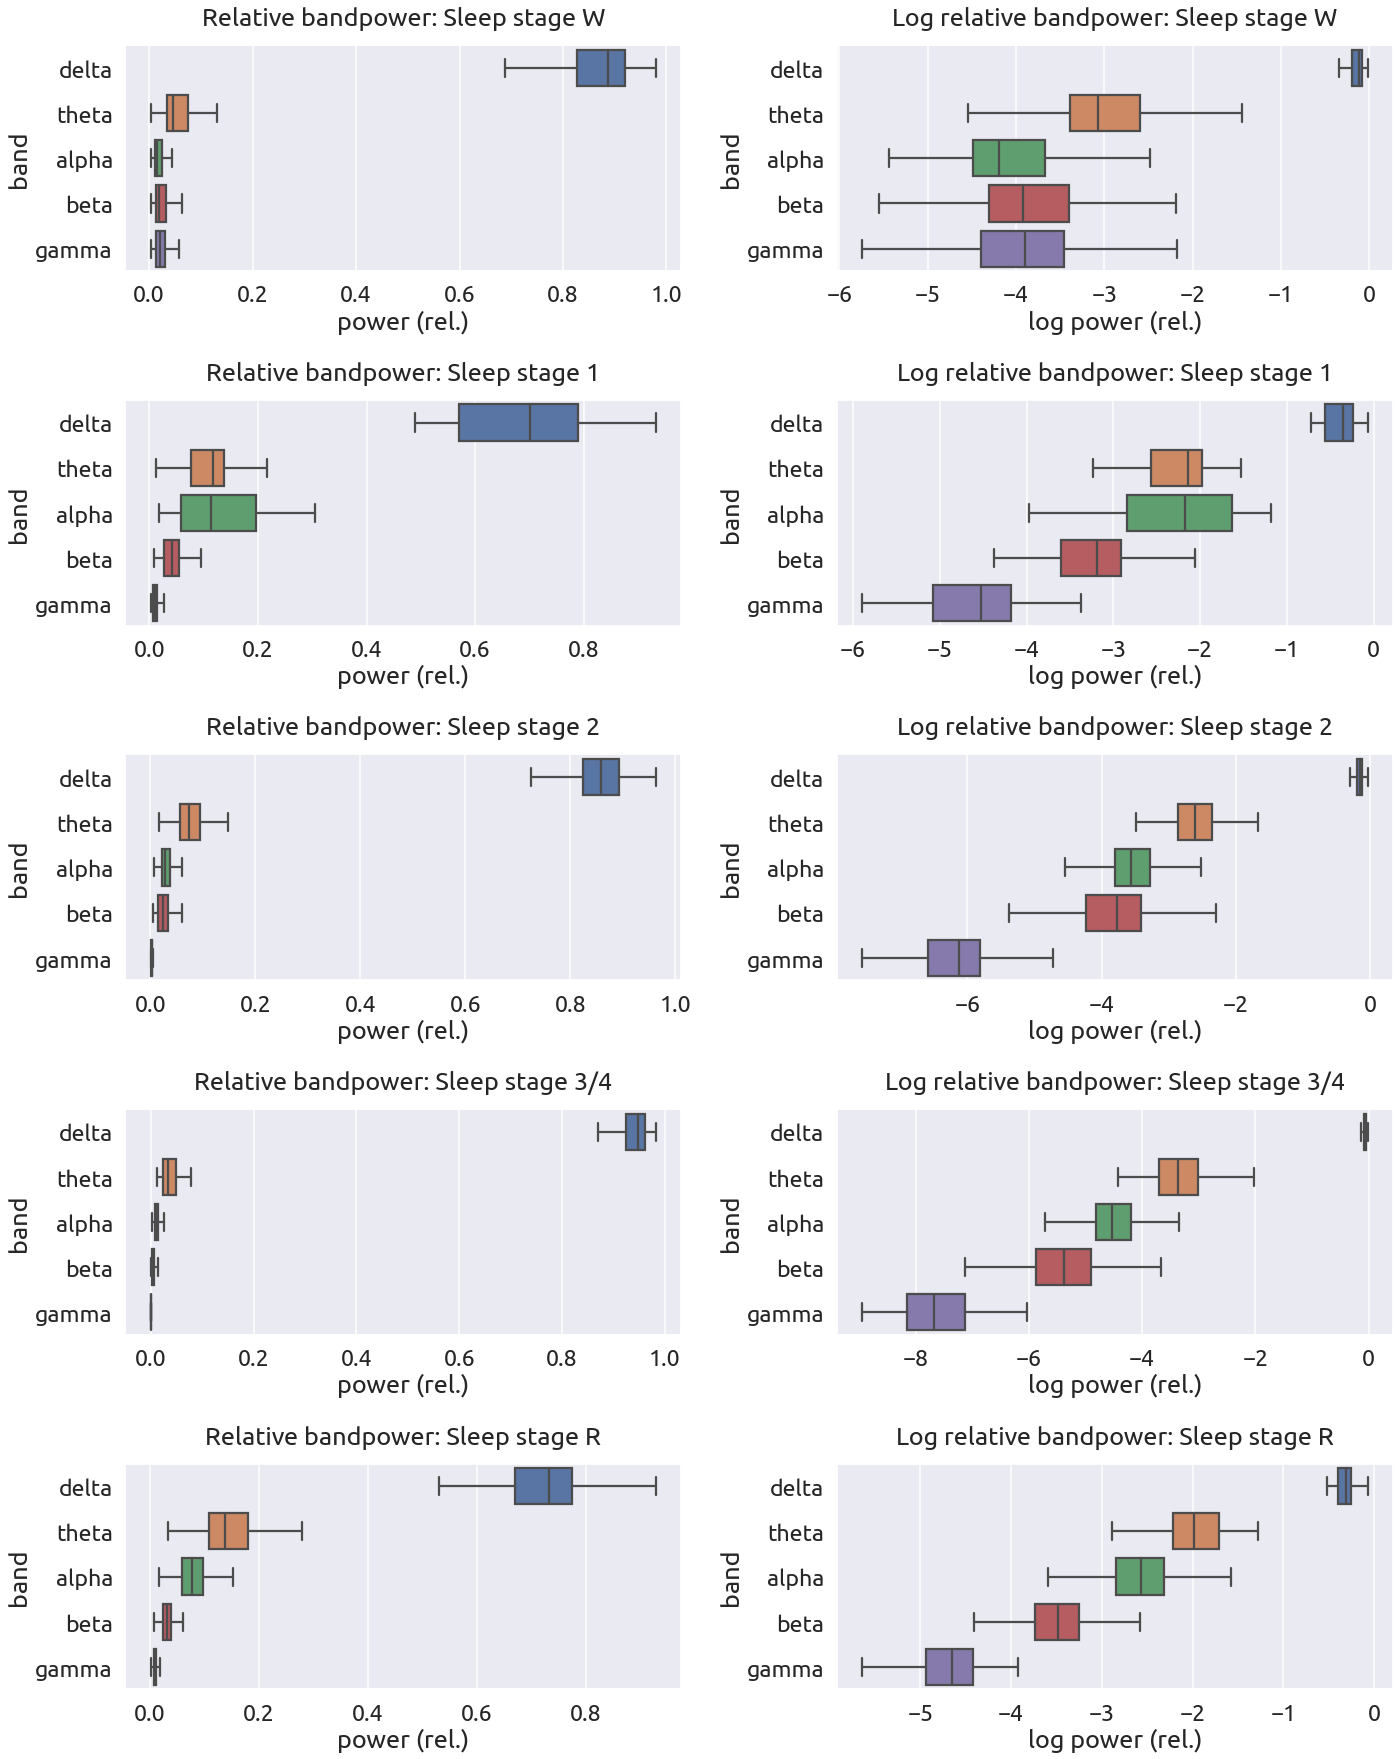

In [25]:
plt.rcParams["figure.figsize"] = (20,25)
plt.subplot()

nrows = len(event_id.keys())
ncols = 2
subplot_count = 1

for event, e_id  in event_id.items():
    sub_epoch_pow_rel_df = pd.DataFrame.from_dict(sleep_stage_rel_bandpower[event]).melt().rename(columns={'variable': 'band', 'value': 'power (rel.)'})
    sub_epoch_pow_log_rel_df = pd.DataFrame.from_dict(sleep_stage_rel_bandpower[event]).melt().rename(columns={'variable': 'band', 'value': 'log power (rel.)'})
    sub_epoch_pow_log_rel_df['log power (rel.)'] = np.log(sub_epoch_pow_log_rel_df['log power (rel.)'])

    # subplot_id = str(len(event_id.keys())) + "2" + str(subplot_count)
    plt.subplot(nrows, ncols, subplot_count)
    sns.boxplot(x='power (rel.)', y='band', data=sub_epoch_pow_rel_df, showfliers = False)# , scale="width")
    plt.title("Relative bandpower: " + event)

    subplot_count += 1

    # subplot_id = str(len(event_id.keys())) + "2" + str(subplot_count)
    plt.subplot(nrows, ncols, subplot_count)
    sns.boxplot(x='log power (rel.)', y='band', data=sub_epoch_pow_log_rel_df, showfliers = False) #, scale="width")
    plt.title("Log relative bandpower: " + event)

    subplot_count += 1

plt.tight_layout()

In [26]:
print(sleep_stage_rel_bandpower['Sleep stage W']['delta'][0])
print(sleep_stage_rel_bandpower['Sleep stage W']['theta'][0])
print(sleep_stage_rel_bandpower['Sleep stage W']['alpha'][0])

0.9031982737377369
0.025885513966336895
0.009812470317050286


In [27]:
# rel_bandpower_values_df = pd.DataFrame()

# for event, e_id in event_id.items():
#     df = pd.DataFrame.from_dict(sleep_stage_rel_bandpower[event])
# #     df['Sleep Stage'] = event
#     df['Sleep Stage Class'] = e_id
    
#     rel_bandpower_values_df = pd.concat([rel_bandpower_values_df, df], ignore_index=True)

temp_data = []
    
for event, e_id in event_id.items():
    df = pd.DataFrame.from_dict(sleep_stage_rel_bandpower[event])
#     df['Sleep Stage'] = event
    df['Sleep Stage Class'] = e_id
    temp_data.append(df)
    
# print(temp_data)
rel_bandpower_values_df = pd.concat(temp_data, ignore_index=True)
rel_bandpower_values_df

,delta,theta,alpha,beta,gamma,Sleep Stage Class
0,0.90,0.03,9.81e-03,0.03,3.34e-02,0
1,0.92,0.02,1.13e-02,0.03,2.71e-02,0
2,0.90,0.04,1.24e-02,0.02,2.09e-02,0
3,0.83,0.09,2.23e-02,0.02,2.95e-02,0
4,0.81,0.10,2.79e-02,0.03,3.54e-02,0
...,...,...,...,...,...,...
1016,0.78,0.12,4.71e-02,0.03,1.33e-02,4
1017,0.71,0.15,7.15e-02,0.05,1.16e-02,4
1018,0.70,0.20,6.58e-02,0.02,5.50e-03,4
1019,0.64,0.15,1.30e-01,0.06,1.14e-02,4


In [28]:
log_rel_bandpower_values_df = rel_bandpower_values_df.copy(deep=True)
for band in rel_bandpower_values_df.columns[:-1]:
    rel_bandpower_values_df[band] = np.log(rel_bandpower_values_df[band])

log_rel_bandpower_values_df

,delta,theta,alpha,beta,gamma,Sleep Stage Class
0,0.90,0.03,9.81e-03,0.03,3.34e-02,0
1,0.92,0.02,1.13e-02,0.03,2.71e-02,0
2,0.90,0.04,1.24e-02,0.02,2.09e-02,0
3,0.83,0.09,2.23e-02,0.02,2.95e-02,0
4,0.81,0.10,2.79e-02,0.03,3.54e-02,0
...,...,...,...,...,...,...
1016,0.78,0.12,4.71e-02,0.03,1.33e-02,4
1017,0.71,0.15,7.15e-02,0.05,1.16e-02,4
1018,0.70,0.20,6.58e-02,0.02,5.50e-03,4
1019,0.64,0.15,1.30e-01,0.06,1.14e-02,4


In [29]:
rel_bandpower_values_df #.iloc[0]

,delta,theta,alpha,beta,gamma,Sleep Stage Class
0,-0.10,-3.65,-4.62,-3.66,-3.40,0
1,-0.09,-4.12,-4.48,-3.54,-3.61,0
2,-0.10,-3.23,-4.39,-3.84,-3.87,0
3,-0.19,-2.37,-3.80,-3.78,-3.52,0
4,-0.22,-2.32,-3.58,-3.52,-3.34,0
...,...,...,...,...,...,...
1016,-0.25,-2.14,-3.05,-3.40,-4.32,4
1017,-0.35,-1.88,-2.64,-2.96,-4.46,4
1018,-0.36,-1.63,-2.72,-3.70,-5.20,4
1019,-0.45,-1.92,-2.04,-2.75,-4.48,4


In [30]:
rel_bandpower_values_df['Sleep Stage Class'].value_counts()

0    368
2    250
3    220
4    125
1     58
Name: Sleep Stage Class, dtype: int64

Note that the dataset is significantly imbalanced. So let's use SMOTE to over-sample to avoid performance issues on the LightGBM.

In [31]:
rel_bandpower_values_df.columns

Index(['delta', 'theta', 'alpha', 'beta', 'gamma', 'Sleep Stage Class'], dtype='object')

In [32]:
NUM_CLASSES = len(rel_bandpower_values_df['Sleep Stage Class'].unique())
NUM_CLASSES

5

In [33]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

dataset_df = rel_bandpower_values_df

X_train, X_test, y_train, y_test = train_test_split(dataset_df[list(dataset_df.columns)[:-1]],
                                                  dataset_df[list(dataset_df.columns)[-1]],
                                                  test_size=0.33,
                                                  random_state=RAND_STATE_INT)

sm = SMOTE(random_state = RAND_STATE_INT)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

In [34]:
pd.DataFrame(y_train_smote).value_counts()

Sleep Stage Class
0                    246
1                    246
2                    246
3                    246
4                    246
dtype: int64

Now our training dataset is balanced.

### Random Forest Classifier

Let's explore whether SMOTE improves performance at all for Random Forest.

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import seaborn

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [36]:
y_pred = rf.predict(X_test)

In [37]:
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Confusion Matrix\n", cm)
print("Confusion Matrix %\n", cm/np.sum(cm))

print("--WEIGHTED---")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("f1 Score:", f1)


print("--MICRO---")
precision = precision_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')
f1 = f1_score(y_test, y_pred, average='micro')
print("Precision:", precision)
print("Recall:", recall)
print("f1 Score:", f1)

print("--MACRO---")
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
print("Precision:", precision)
print("Recall:", recall)
print("f1 Score:", f1)

Confusion Matrix
 [[119   3   0   0   0]
 [  5   8   3   0   5]
 [  0   0  76  10   1]
 [  3   0   3  62   0]
 [  1   4   1   0  33]]
Confusion Matrix %
 [[0.35311573 0.00890208 0.         0.         0.        ]
 [0.0148368  0.02373887 0.00890208 0.         0.0148368 ]
 [0.         0.         0.22551929 0.02967359 0.00296736]
 [0.00890208 0.         0.00890208 0.18397626 0.        ]
 [0.00296736 0.01186944 0.00296736 0.         0.09792285]]
--WEIGHTED---
Accuracy: 0.884272997032641
Precision: 0.8778637423085021
Recall: 0.884272997032641
f1 Score: 0.8798045698991764
--MICRO---
Precision: 0.884272997032641
Recall: 0.884272997032641
f1 Score: 0.884272997032641
--MACRO---
Precision: 0.81718968824014
Recall: 0.7975687974889917
f1 Score: 0.8044860446742799


<AxesSubplot:>

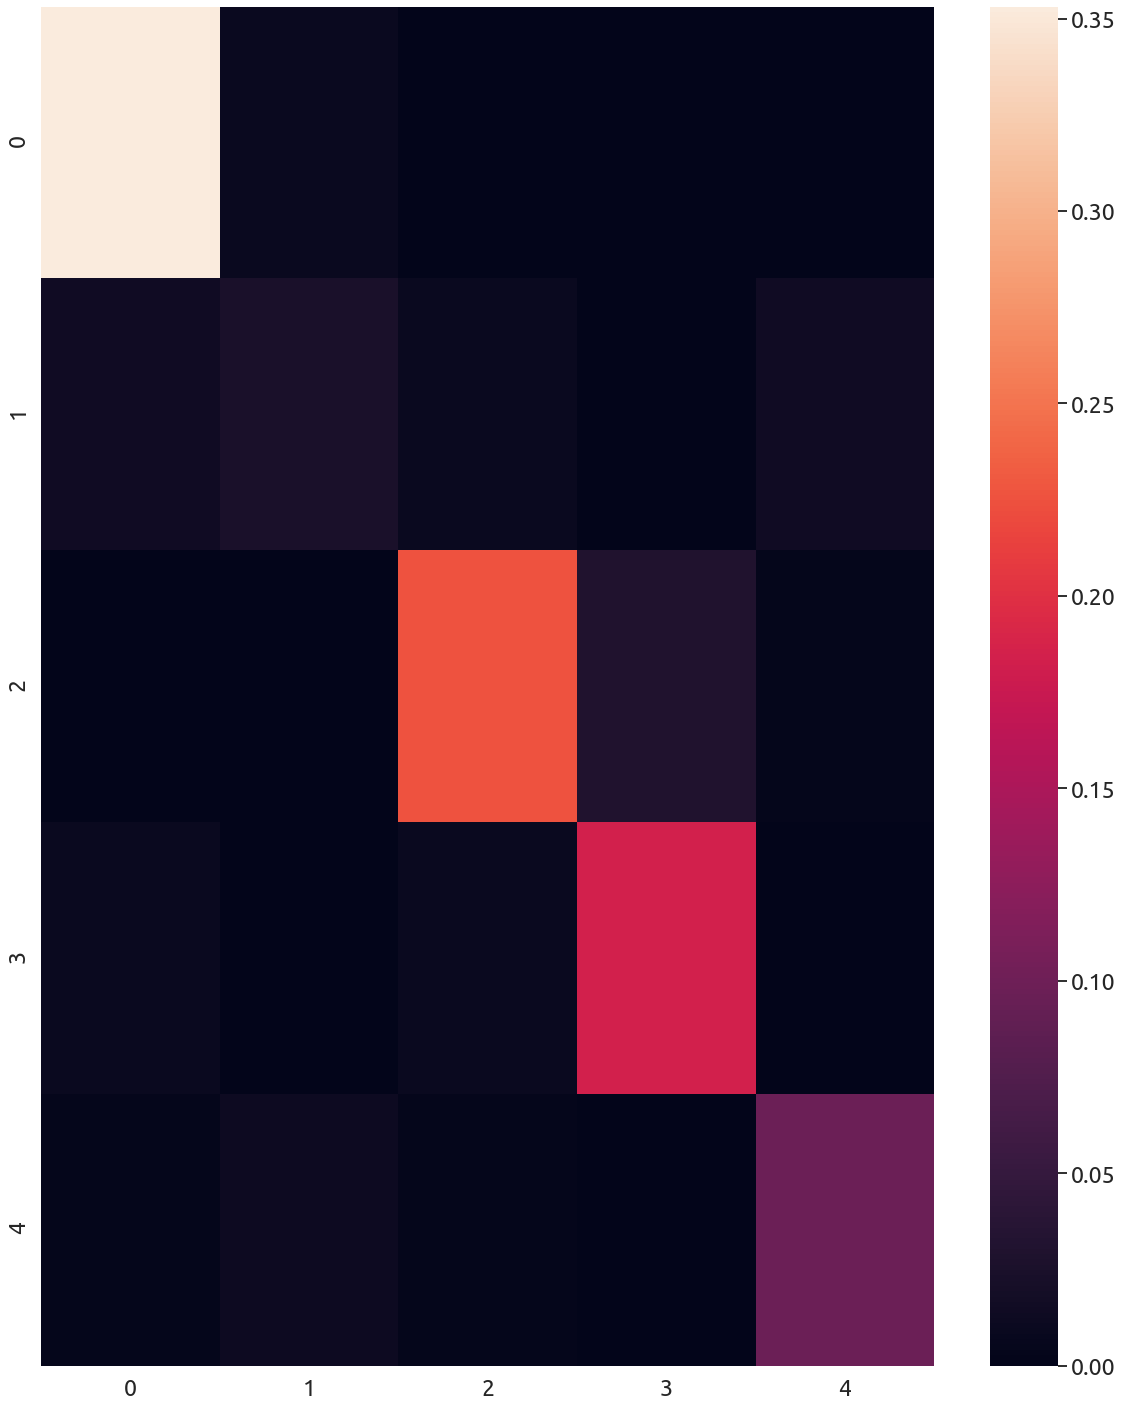

In [38]:
seaborn.heatmap(cm/np.sum(cm))

In [39]:
rf_smote = RandomForestClassifier()
rf_smote.fit(X_train_smote, y_train_smote)

y_pred = rf_smote.predict(X_test)

In [40]:
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Confusion Matrix\n", cm)
print("Confusion Matrix %\n", cm/np.sum(cm))

print("--WEIGHTED---")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("f1 Score:", f1)


print("--MICRO---")
precision = precision_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')
f1 = f1_score(y_test, y_pred, average='micro')
print("Precision:", precision)
print("Recall:", recall)
print("f1 Score:", f1)

print("--MACRO---")
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
print("Precision:", precision)
print("Recall:", recall)
print("f1 Score:", f1)

Confusion Matrix
 [[113   7   0   1   1]
 [  1  15   1   0   4]
 [  0   5  70  11   1]
 [  3   0   5  60   0]
 [  0   7   1   0  31]]
Confusion Matrix %
 [[0.33531157 0.02077151 0.         0.00296736 0.00296736]
 [0.00296736 0.04451039 0.00296736 0.         0.01186944]
 [0.         0.0148368  0.20771513 0.03264095 0.00296736]
 [0.00890208 0.         0.0148368  0.17804154 0.        ]
 [0.         0.02077151 0.00296736 0.         0.09198813]]
--WEIGHTED---
Accuracy: 0.857566765578635
Precision: 0.8769347689752648
Recall: 0.857566765578635
f1 Score: 0.8640604113746957
--MICRO---
Precision: 0.857566765578635
Recall: 0.857566765578635
f1 Score: 0.857566765578635
--MACRO---
Precision: 0.7974501033324563
Recall: 0.8244675319360253
f1 Score: 0.8035304214855297


### LightGBM
Let's try to use a gradient boosting model:

In [41]:
import optuna.integration.lightgbm as lgb

from sklearn.model_selection import train_test_split, RepeatedKFold
from imblearn.over_sampling import SMOTE

import lightgbm as lgb
from lightgbm import early_stopping
# from lightgbm import log_evaluation

import optuna
import optuna.integration.lightgbm as optuna_lgb

datasets_dfs = {"Relative Bandpower": rel_bandpower_values_df,
                "Log Relative Bandpower": log_rel_bandpower_values_df}

for feature_type, dataset_df in datasets_dfs.items():
    X_train, X_test, y_train, y_test = train_test_split(dataset_df[list(dataset_df.columns)[:-1]],
                                                      dataset_df[list(dataset_df.columns)[-1]],
                                                      test_size=0.33,
                                                      random_state=RAND_STATE_INT)
    
    sm = SMOTE(random_state = RAND_STATE_INT)
    X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)
    
    d_train = lgb.Dataset(X_train_smote, label=y_train_smote)
    d_test = lgb.Dataset(X_test, label=y_test)

    
    rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=RAND_STATE_INT)

    params = {
            "objective": "multiclass",
            "num_classes": NUM_CLASSES,
            "metric": "multi_logloss",
            "verbosity": -1,
            "boosting_type": "gbdt",                
            "seed": RAND_STATE_INT
        }
    
    study_tuner = optuna.create_study(direction='minimize')

    # Suppress information only outputs - otherwise optuna is 
    # quite verbose, which can be nice, but takes up a lot of space
    optuna.logging.set_verbosity(optuna.logging.WARNING) 
    
    # Run optuna LightGBMTunerCV tuning of LightGBM with cross-validation
    tuner = optuna_lgb.LightGBMTunerCV(params, 
                                       d_train,
                                       study=study_tuner,
                                       verbose_eval=False,                            
                                       early_stopping_rounds=10,
                                       time_budget=900, # in seconds -> 1 hours
                                       seed = RAND_STATE_INT,
                                       folds=rkf,
                                       num_boost_round=50,
    #                                    callbacks=[
    #                                        optuna_lgb.reset_parameter(
    #                                            learning_rate = [0.09]*100 + \
    #                                                            [0.05]*50 + \
    #                                                            [0.01]*30 + \
    #                                                            [0.005]*20
    #                                    )]
    )
    
    tuner.run()

    evals={}
    model = lgb.train(tuner.best_params,
                      train_set = d_train, 
                      valid_sets=[d_train, d_test],
                      callbacks = [lgb.record_evaluation(evals)],
                      verbose_eval=False,
                      num_boost_round=100)

    y_score = model.predict(X_test)

    y_pred = np.argmax(y_score, axis=1)

    cm = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print("---------------------" + feature_type + "---------------------")
    print("Confusion Matrix\n", cm)
    print("Confusion Matrix %\n", cm/np.sum(cm))
    
    print("--WEIGHTED---")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("f1 Score:", f1)
    
    
    print("--MICRO---")
    precision = precision_score(y_test, y_pred, average='micro')
    recall = recall_score(y_test, y_pred, average='micro')
    f1 = f1_score(y_test, y_pred, average='micro')
    print("Precision:", precision)
    print("Recall:", recall)
    print("f1 Score:", f1)
    
    print("--MACRO---")
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    print("Precision:", precision)
    print("Recall:", recall)
    print("f1 Score:", f1)

[I 2025-08-13 17:34:53,142] A new study created in memory with name: no-name-2b86d6cc-d04c-48b6-87d2-d99a87658a24
feature_fraction, val_score: inf:   0%|          | 0/7 [00:00<?, ?it/s]

---------------------Relative Bandpower---------------------
Confusion Matrix
 [[115   6   0   0   1]
 [  2  14   2   0   3]
 [  0   1  75  10   1]
 [  3   0   4  61   0]
 [  0   7   0   0  32]]
Confusion Matrix %
 [[0.34124629 0.01780415 0.         0.         0.00296736]
 [0.00593472 0.04154303 0.00593472 0.         0.00890208]
 [0.         0.00296736 0.22255193 0.02967359 0.00296736]
 [0.00890208 0.         0.01186944 0.1810089  0.        ]
 [0.         0.02077151 0.         0.         0.09495549]]
--WEIGHTED---
Accuracy: 0.8813056379821959
Precision: 0.8905771132439749
Recall: 0.8813056379821959
f1 Score: 0.884731582054243
--MICRO---
Precision: 0.8813056379821959
Recall: 0.8813056379821959
f1 Score: 0.8813056379821959
--MACRO---
Precision: 0.8216558107403179
Recall: 0.8377860454091625
f1 Score: 0.8269004084621446


min_data_in_leaf, val_score: 0.344386: 100%|##########| 5/5 [00:34<00:00,  6.81s/it]


---------------------Log Relative Bandpower---------------------
Confusion Matrix
 [[114   7   0   0   1]
 [  2  12   3   0   4]
 [  0   4  73  10   0]
 [  3   0   7  58   0]
 [  0   6   1   0  32]]
Confusion Matrix %
 [[0.33827893 0.02077151 0.         0.         0.00296736]
 [0.00593472 0.03560831 0.00890208 0.         0.01186944]
 [0.         0.01186944 0.21661721 0.02967359 0.        ]
 [0.00890208 0.         0.02077151 0.17210682 0.        ]
 [0.         0.01780415 0.00296736 0.         0.09495549]]
--WEIGHTED---
Accuracy: 0.857566765578635
Precision: 0.869140882311924
Recall: 0.857566765578635
f1 Score: 0.8623795078767755
--MICRO---
Precision: 0.857566765578635
Recall: 0.857566765578635
f1 Score: 0.857566765578635
--MACRO---
Precision: 0.7917259914217318
Recall: 0.8036778515380585
f1 Score: 0.7949811401010867


Tuning hyperparameters using k-fold cross-validation:

In [42]:
# params = {
#     "objective": "binary",
#     "metric": "binary_logloss",
#     "verbosity": -1,
#     "boosting_type": "gbdt",
#     "num_leaves": 31,
#     "max_depth": -1,
#     "learning_rate": 0.1,
#     "n_estimators": 100,
#     "subsample_for_bin": 200000,
# #     sample_pos_weight 
#     "min_split_gain": 0.0,
#     "min_child_weight": 0.001,
#     "min_child_samples": 20,
#     "colsample_bytree": 1.0,
#     "reg_alpha": 0.0,
#     "reg_lambda": 0.0
# }

In [43]:


# rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=RAND_STATE_INT)
# # rkf = RepeatedKFold(n_splits=2, n_repeats=2, random_state=RAND_STATE_INT)

# params = {
#         "objective": "multiclass",
#         "num_classes": NUM_CLASSES,
#         "metric": "multi_logloss",
#         "verbosity": -1,
#         "boosting_type": "gbdt",                
#         "seed": RAND_STATE_INT
#     }

# study_tuner = optuna.create_study(direction='minimize')

# # Suppress information only outputs - otherwise optuna is 
# # quite verbose, which can be nice, but takes up a lot of space
# optuna.logging.set_verbosity(optuna.logging.WARNING) 

# # Run optuna LightGBMTunerCV tuning of LightGBM with cross-validation
# tuner = optuna_lgb.LightGBMTunerCV(params, 
#                                    d_train,
#                                    study=study_tuner,
#                                    verbose_eval=False,                            
#                                    early_stopping_rounds=10,
#                                    time_budget=1800, # in seconds -> 2 hours
#                                    seed = RAND_STATE_INT,
#                                    folds=rkf,
#                                    num_boost_round=50,
# #                                    callbacks=[
# #                                        optuna_lgb.reset_parameter(
# #                                            learning_rate = [0.09]*100 + \
# #                                                            [0.05]*50 + \
# #                                                            [0.01]*30 + \
# #                                                            [0.005]*20
# #                                    )]
# )

# tuner.run()

In [44]:
# tuner.best_params

In [45]:
# import lightgbm as lgb

# evals={}
# model = lgb.train(tuner.best_params,
#                   train_set = d_train, 
#                   valid_sets=[d_train, d_test],
#                   callbacks = [lgb.record_evaluation(evals)],
#                   verbose_eval=False,
#                   num_boost_round=100)

In [46]:
# y_score = model.predict(X_test)

In [47]:
# y_pred = np.argmax(y_score, axis=1)
# y_pred.shape

In [48]:
# unique_values, counts = np.unique(y_pred, return_counts=True)
# counts

In [49]:
# cm = confusion_matrix(y_test, y_pred)
# accuracy = accuracy_score(y_test, y_pred)
# precision = precision_score(y_test, y_pred, average='weighted')
# recall = recall_score(y_test, y_pred, average='weighted')
# f1 = f1_score(y_test, y_pred, average='weighted')

# print("Confusion Matrix\n", cm)
# print("Confusion Matrix %\n", cm/np.sum(cm))

# print("--WEIGHTED---")
# print("Accuracy:", accuracy)
# print("Precision:", precision)
# print("Recall:", recall)
# print("f1 Score:", f1)


# print("--MICRO---")
# precision = precision_score(y_test, y_pred, average='micro')
# recall = recall_score(y_test, y_pred, average='micro')
# f1 = f1_score(y_test, y_pred, average='micro')
# print("Precision:", precision)
# print("Recall:", recall)
# print("f1 Score:", f1)

# print("--MACRO---")
# precision = precision_score(y_test, y_pred, average='macro')
# recall = recall_score(y_test, y_pred, average='macro')
# f1 = f1_score(y_test, y_pred, average='macro')
# print("Precision:", precision)
# print("Recall:", recall)
# print("f1 Score:", f1)

In [50]:
# seaborn.heatmap(cm/np.sum(cm))

### Simple Feed-forward Neural Network
(Coming soon!)

In [51]:
# import torch
# import torch.nn as nn
# import pytorch_lightning as pl

In [52]:
# class TabularDataset(torch.utils.data.Dataset):
    
#     def __init__(self, df, feature_cols, class_col):
#         self.df = df
#         self.feature_cols = feature_cols
#         self.class_col = class_col
    
#     def __len__(self):
#         return len(self.df)
        
#     def __getitem__(self, idx):
#         return (torch.DoubleTensor(self.df[self.feature_cols].iloc[idx].tolist()),
#                torch.FloatTensor(self.df[self.class_col].iloc[idx].tolist()))

In [53]:
# # rel_bandpower_values_df.columns[:-2].tolist()
# rel_bp_dataset = TabularDataset(rel_bandpower_values_df,
#                                 rel_bandpower_values_df.columns[:-2].tolist(),
#                                 rel_bandpower_values_df.columns[-1])

# row, target = rel_bp_dataset.__getitem__(100)
# print("Row, target:", row, target)
# print("Row sample value:", row.numpy()[0])
# print("Types:", type(row), type(target))

In [54]:
# class BasicModel(pl.LightningModule):
    
#     def __init__(self):
#         super.__init__()
        
#         model = nn.Sequential(
#             nn.Linear(5, 5), # 5 bandpower features
#             nn.ReLU(),
#             nn.Linear(5,5),
#             nn.ReLU(),
#             nn.LogSoftmax()
#         )
    
#     def forward(x):
#         return self.model(x)
    
#     def training_step(self, batch, batch_idx):
        